In [403]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import cv2 as cv
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import math

In [404]:
device = torch.device('mps')

In [405]:
model = smp.Unet(encoder_name='efficientnet-b0', encoder_weights='imagenet', in_channels=3, classes=1).to(device)

In [406]:
model.load_state_dict(torch.load('./data/model_weights_skin_segmentation_ham10000.pth', map_location='mps'))

<All keys matched successfully>

In [407]:
def segmentate(image_path, model):
    img = cv.imread(image_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (256,256))
    img = img.astype('float32') / 255.0
    img_tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        output = torch.sigmoid(output).cpu().squeeze().numpy()
        mask = (output > 0.3).astype(np.uint8)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title("Original image")
    plt.imshow(img)

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')

    return mask
    

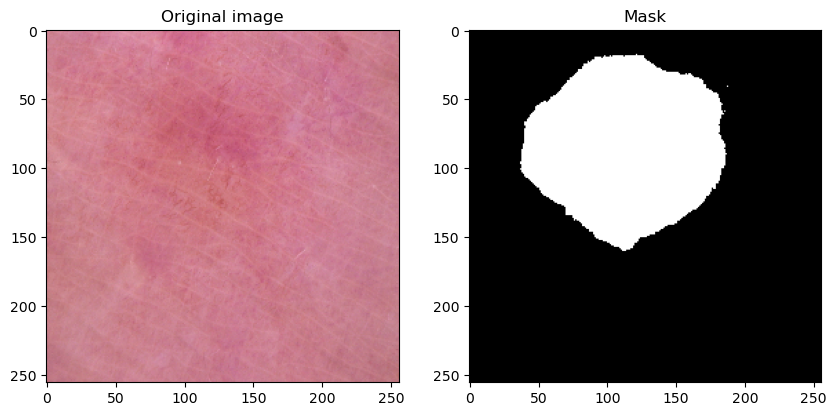

In [408]:
path = './ISIC/Train/dermatofibroma/ISIC_0027044.jpg'
mask = segmentate(path, model)

In [409]:
# Extracción de características se regirá por la regla ABCD
# A Asimetría
# B Borde
# C Color
# D diámetro

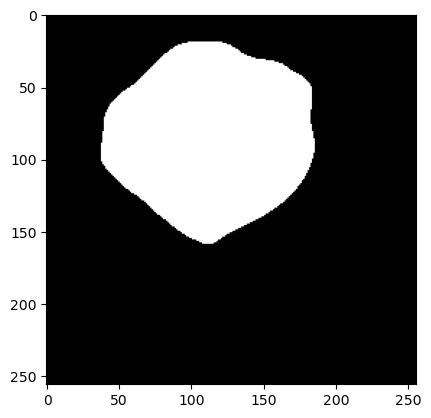

In [410]:
# Apply blur to the mask
kernel = np.ones((15,15), np.uint8)
morph_op = cv.morphologyEx(mask, cv.MORPH_DILATE, kernel, iterations=1)
morph_op = cv.morphologyEx(morph_op, cv.MORPH_ERODE, kernel, iterations=1)

blur_mask = cv.blur(morph_op, (15,15)).astype(np.uint8)
plt.imshow(blur_mask, cmap='gray')

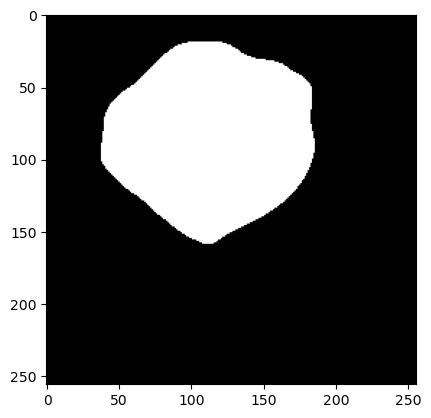

In [411]:
(h,w) = mask.shape[:2]
mask_contours = np.zeros((h,w))
edges = cv.Canny(blur_mask, 100, 200)

contours, hierarchy = cv.findContours(blur_mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

contour_max = max(contours, key=cv.contourArea)

cv.drawContours(mask_contours, [contour_max], -1, 255, -1)
plt.imshow(mask_contours, cmap='gray')

El diametro es: 148


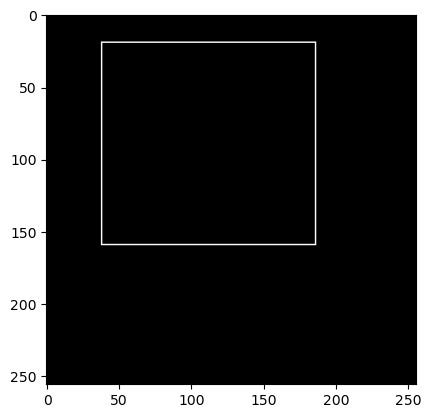

In [412]:
mask_bounding_rectangle = np.zeros((h,w))
x,y,w,h = cv.boundingRect(mask_contours.astype(np.uint8))
cv.rectangle(mask_bounding_rectangle, (x,y), (x+w, y+h), 255)
plt.imshow(mask_bounding_rectangle, cmap='gray')
diameter = max(w,h)
print(f"El diametro es: {diameter}")

In [413]:
# Borde
# Para esto calculamos circularidad
# Necesitamos área y el perimetro anteriormente calculado
perimeter = cv.arcLength(contour_max, True)
area = cv.contourArea(contour_max)

if perimeter > 0:
    circularity = ((4*math.pi*area)/(perimeter*perimeter))


print(circularity)


0.8636784489193874


In [414]:
# image_original = cv.imread(path, cv.IMREAD_COLOR_RGB).astype(np.uint8)
# image_original = cv.resize(image_original, (256,256))

# res = cv.bitwise_and(image_original, image_original, mask=contour_max)

# plt.imshow(image_original)
# plt.imshow(blur_mask, cmap='jet', alpha=0.5)

In [415]:
# Asimetría

mask_flip_y = cv.flip(mask_contours, 1)
mask_flip_x = cv.flip(mask_contours, 0)

symmetry_comparison_y = cv.absdiff(mask_contours, mask_flip_y)
symmetry_comparison_x = cv.absdiff(mask_contours, mask_flip_x)

total_y = np.sum(symmetry_comparison_y)/area
total_x = np.sum(symmetry_comparison_x)/area

print(total_y, total_x)


130.5950368517141 393.78524579079044


In [416]:
image_original

array([[[148, 134, 206],
        [153, 136, 209],
        [158, 142, 213],
        ...,
        [145, 131, 203],
        [137, 125, 197],
        [146, 129, 203]],

       [[143, 132, 202],
        [143, 134, 201],
        [148, 137, 209],
        ...,
        [141, 128, 202],
        [133, 121, 197],
        [139, 127, 203]],

       [[144, 133, 206],
        [139, 132, 205],
        [138, 133, 202],
        ...,
        [136, 123, 199],
        [135, 122, 196],
        [133, 120, 198]],

       ...,

       [[133, 120, 194],
        [131, 120, 193],
        [126, 115, 188],
        ...,
        [121, 120, 184],
        [130, 120, 190],
        [130, 123, 190]],

       [[124, 118, 197],
        [121, 112, 185],
        [122, 114, 185],
        ...,
        [124, 116, 186],
        [127, 119, 184],
        [116, 118, 183]],

       [[128, 123, 198],
        [123, 114, 187],
        [123, 116, 191],
        ...,
        [124, 120, 191],
        [125, 120, 189],
        [118, 117, 185]]

saturation std: 10.214249332287006 vue std 5.424435030479015


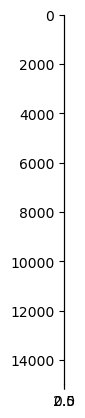

In [417]:
# Color variation

image_original = cv.imread(path).astype(np.uint8)
image_original_hsv = cv.cvtColor(image_original, cv.COLOR_BGR2HSV)
image_original_hsv = cv.resize(image_original, (256,256))

res = cv.bitwise_and(image_original_hsv, image_original_hsv, mask=mask_contours.astype(np.uint8))

res_test = res[mask_contours > 0]

# Split color channels

h,s,v = cv.split(res)

s = s[mask_contours>0]
v = v[mask_contours>0]

saturation_std = np.std(s)
vue_std = np.std(v)

print(f"saturation std: {saturation_std} vue std {vue_std}")

plt.imshow(res_test)
